# 03 — Model Evaluation
**Sign2Chat — UAE Sign Language Recognition**

Evaluates the trained CNN+BiLSTM model on the held-out test set.

### Input
- `../models/uaesl_best.keras` — best model from notebook 02
- `../models/uaesl_class_index.json` — index-to-class mapping
- `../UAE-dataset/landmarks_index.csv` — **original** (non-augmented) split index

### Output
- `../models/uaesl_results.json` — evaluation metrics
- Console: Top-1, Top-5, Top-10, per-class report, confusion matrix


In [1]:
import os
os.environ["XLA_FLAGS"]    = "--xla_gpu_autotune_level=0"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
print("✅ XLA autotuning disabled")

✅ XLA autotuning disabled


In [2]:
!pip install -q seaborn scikit-learn matplotlib

In [12]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ─────────────────────────────────────────────────────────────────────
INDEX_CSV      = '../UAE-dataset/landmarks_index.csv'        # original, no augmentation
CLASS_IDX_PATH = '../models/uaesl_class_index.json'
BEST_MODEL     = '../models/uaesl_best.keras'
RESULTS_CSV     = '../results/uaesl_results.csv'

MAX_FRAMES  = 180
FEATURE_DIM = 165
BATCH_SIZE  = 32
DROPOUT     = 0.4
L2_REG      = 1e-3

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

print(f'✅ TensorFlow {tf.__version__}')
print(f'   GPU: {gpus[0].name if gpus else "CPU"}')


from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Masking, TimeDistributed, BatchNormalization,
    Dropout, Bidirectional, LSTM, Dense
)
from tensorflow.keras.regularizers import l2

def build_model(num_classes, max_frames, feature_dim):
    model = Sequential([
        Masking(mask_value=0.0, input_shape=(max_frames, feature_dim)),
        TimeDistributed(Dense(128, activation='relu')),
        BatchNormalization(), Dropout(DROPOUT),
        TimeDistributed(Dense(128, activation='relu')),
        BatchNormalization(), Dropout(DROPOUT),
        Bidirectional(LSTM(128, return_sequences=False, use_cudnn=False)),
        BatchNormalization(), Dropout(DROPOUT),
        Dense(256, activation='relu', kernel_regularizer=l2(L2_REG)),
        BatchNormalization(), Dropout(DROPOUT),
        Dense(num_classes, activation='softmax', dtype='float32',
              kernel_regularizer=l2(L2_REG)),
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')],
    )
    return model


✅ TensorFlow 2.21.0
   GPU: /physical_device:GPU:0


## Step 1 — Load Class Index & Test Split

In [13]:
with open(CLASS_IDX_PATH) as f:
    class_idx = json.load(f)

NUM_CLASSES = len(class_idx)
idx_to_name = {int(k): v['clean_name'] for k, v in class_idx.items()}
print(f'✅ {NUM_CLASSES} classes loaded')

# Build label_id → class_index mapping (sorted by label_id = notebook 02 order)
label_ids_sorted = sorted(int(v['label_id']) for v in class_idx.values())
label_id_to_idx  = {lid: idx for idx, lid in enumerate(label_ids_sorted)}

# Load original index (no augmented samples)
df = pd.read_csv(INDEX_CSV)
print(f'   Total rows in index: {len(df)}')
print(df['split'].value_counts().to_string())


✅ 34 classes loaded
   Total rows in index: 1239
split
train    850
test     203
val      186


## Step 2 — Load Test Set

In [14]:
def load_split(df, split):
    rows = df[df['split'] == split].reset_index(drop=True)
    X = np.zeros((len(rows), MAX_FRAMES, FEATURE_DIM), dtype=np.float32)
    y = np.zeros(len(rows), dtype=np.int32)
    missing = []
    for i, row in rows.iterrows():
        path = row['npy_path']
        if not os.path.exists(path):
            missing.append(path)
            continue
        seq = np.load(path)
        if seq.shape != (MAX_FRAMES, FEATURE_DIM):
            if seq.shape[1] == FEATURE_DIM:
                n = min(seq.shape[0], MAX_FRAMES)
                X[i, -n:] = seq[-n:]
            else:
                missing.append(path)
                continue
        else:
            X[i] = seq
        y[i] = label_id_to_idx[row['label_id']]
    if missing:
        print(f'⚠️  {len(missing)} missing files skipped')
    return X, y

X_test, y_test = load_split(df, 'test')
print(f'✅ Test set: X={X_test.shape}  y={y_test.shape}')
print(f'   Value range: [{X_test.min():.3f}, {X_test.max():.3f}]')


✅ Test set: X=(203, 180, 165)  y=(203,)
   Value range: [-1.875, 1.807]


## Step 3 — Load Model & Run Predictions

In [15]:
assert os.path.exists(BEST_MODEL), f'Model not found: {BEST_MODEL}\nRun notebook 02 first.'

# Rebuild with use_cudnn=False so left-padded masks (zeros-at-front) work
model = build_model(NUM_CLASSES, MAX_FRAMES, FEATURE_DIM)
model.load_weights(BEST_MODEL)
print(f'✅ Model weights loaded from: {BEST_MODEL}')
print(f'   Input  shape: {model.input_shape}')
print(f'   Output shape: {model.output_shape}')
print(f'   Parameters  : {model.count_params():,}')

y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
print(f'\n✅ Predictions done — {len(y_pred)} samples')

✅ Model weights loaded from: ../models/uaesl_best.keras
   Input  shape: (None, 180, 165)
   Output shape: (None, 34)
   Parameters  : 378,530
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 776ms/step

✅ Predictions done — 203 samples


## Step 4 — Top-1 / Top-5 / Top-10 Accuracy

In [16]:
def topk_accuracy(y_true, y_probs, k):
    correct = sum(
        y_true[i] in np.argsort(y_probs[i])[-k:]
        for i in range(len(y_true))
    )
    return correct / len(y_true)

top1  = topk_accuracy(y_test, y_pred_probs, 1)
top5  = topk_accuracy(y_test, y_pred_probs, 5)
top10 = topk_accuracy(y_test, y_pred_probs, 10)

print('╔══════════════════════════╗')
print('║  Test-Set Accuracy       ║')
print('╠══════════════════════════╣')
print(f'║  Top-1  : {top1*100:6.2f}%         ║')
print(f'║  Top-5  : {top5*100:6.2f}%         ║')
print(f'║  Top-10 : {top10*100:6.2f}%         ║')
print('╚══════════════════════════╝')


╔══════════════════════════╗
║  Test-Set Accuracy       ║
╠══════════════════════════╣
║  Top-1  :  99.51%         ║
║  Top-5  : 100.00%         ║
║  Top-10 : 100.00%         ║
╚══════════════════════════╝


## Step 5 — Per-Class Report (Best / Worst 10)

In [17]:
per_class = {}
for idx in range(NUM_CLASSES):
    mask = y_test == idx
    if mask.sum() == 0:
        continue
    acc = (y_pred[mask] == idx).mean()
    per_class[idx_to_name[idx]] = {
        'class_idx': idx,
        'acc':       round(float(acc) * 100, 1),
        'n_test':    int(mask.sum()),
    }

sorted_acc = sorted(per_class.items(), key=lambda x: x[1]['acc'])

print(f'  {"Class":<25} {"Acc":>6}   {"Test samples":>12}')
print(f'  {"-"*25} {"-"*6}   {"-"*12}')

print('\n  --- Bottom 10 ---')
for name, d in sorted_acc[:10]:
    print(f'  {name:<25} {d["acc"]:>5.1f}%   {d["n_test"]:>12}')

print('\n  --- Top 10 ---')
for name, d in sorted_acc[-10:][::-1]:
    print(f'  {name:<25} {d["acc"]:>5.1f}%   {d["n_test"]:>12}')


  Class                        Acc   Test samples
  ------------------------- ------   ------------

  --- Bottom 10 ---
  Red                        83.3%              6
  Cat                       100.0%              6
  Elephant                  100.0%              6
  Fish                      100.0%              6
  Camel                     100.0%              6
  Slow                      100.0%              6
  Fatigue                   100.0%              6
  Hungry                    100.0%              6
  Beautiful                 100.0%              6
  Hot                       100.0%              6

  --- Top 10 ---
  Walk                      100.0%              6
  Write                     100.0%              6
  Read                      100.0%              6
  Think                     100.0%              6
  Angry                     100.0%              6
  Work                      100.0%              6
  Orange                    100.0%              6
  Green    

## Step 6 — Confusion Matrix

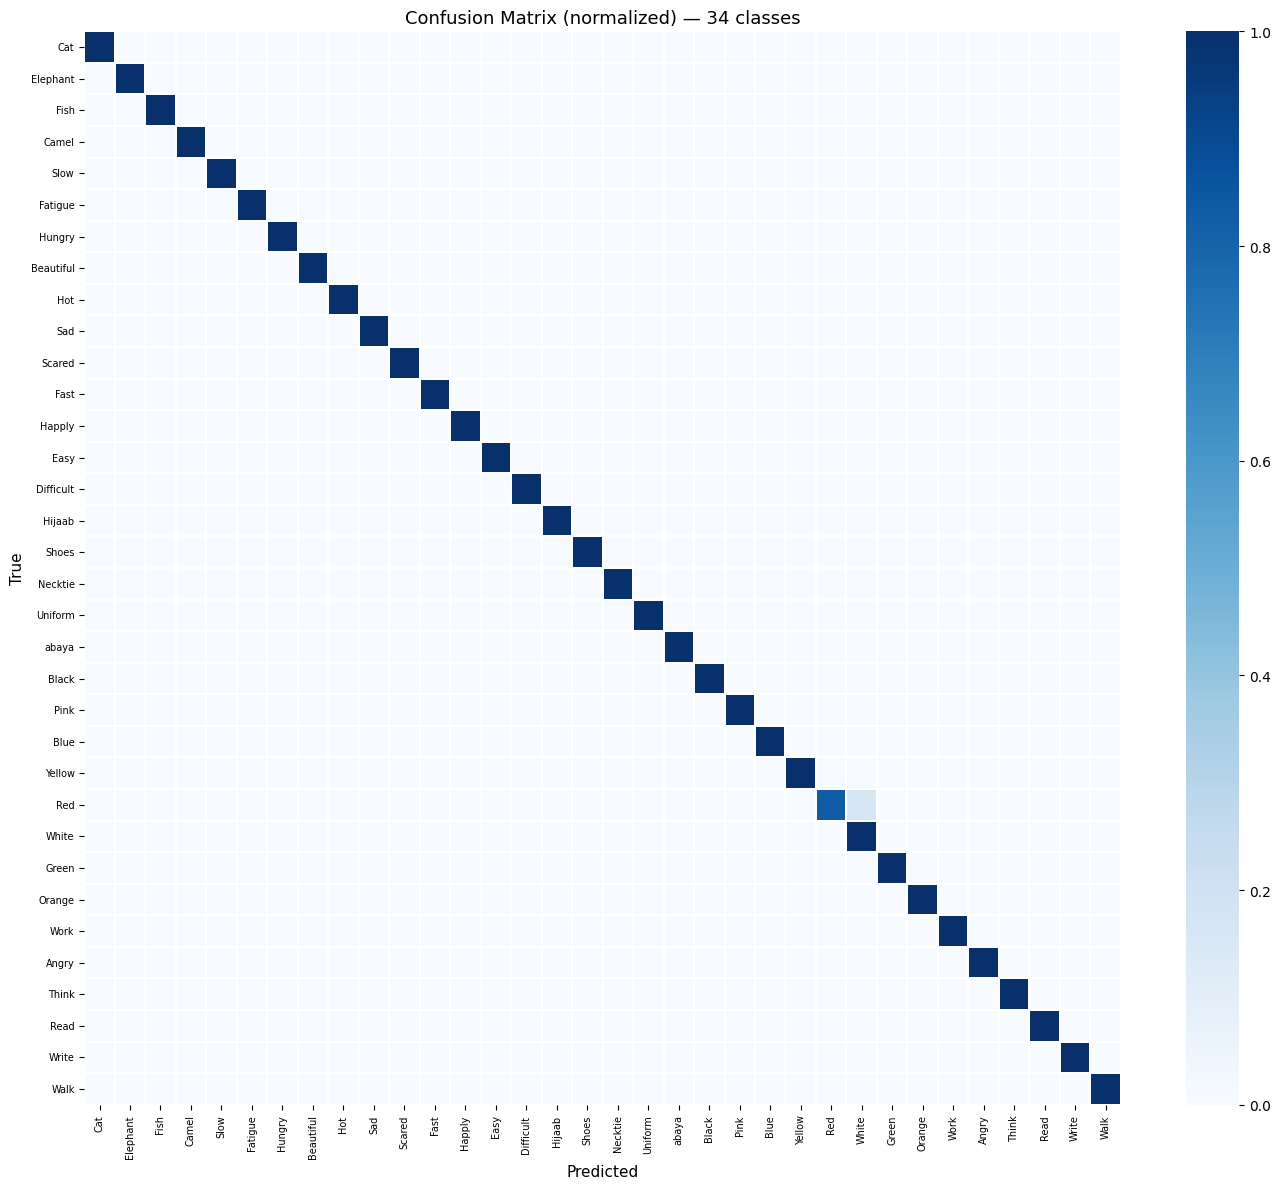

✅ Confusion matrix saved → ../models/uaesl_confusion_matrix.png


In [18]:
fig, ax = plt.subplots(figsize=(14, 12))
class_names = [idx_to_name[i] for i in range(NUM_CLASSES)]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

sns.heatmap(
    cm_norm,
    ax=ax,
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0, vmax=1,
    linewidths=0.3,
    annot=False,
)
ax.set_title(f'Confusion Matrix (normalized) — {NUM_CLASSES} classes', fontsize=13)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig('../models/uaesl_confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved → ../models/uaesl_confusion_matrix.png')


## Step 7 — Sklearn Classification Report

In [19]:
target_names = [idx_to_name[i] for i in range(NUM_CLASSES)]
report = classification_report(y_test, y_pred, target_names=target_names, zero_division=0)
print(report)


              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00         6
    Elephant       1.00      1.00      1.00         6
        Fish       1.00      1.00      1.00         6
       Camel       1.00      1.00      1.00         6
        Slow       1.00      1.00      1.00         6
     Fatigue       1.00      1.00      1.00         6
      Hungry       1.00      1.00      1.00         6
   Beautiful       1.00      1.00      1.00         6
         Hot       1.00      1.00      1.00         6
         Sad       1.00      1.00      1.00         6
      Scared       1.00      1.00      1.00         7
        Fast       1.00      1.00      1.00         6
      Happly       1.00      1.00      1.00         6
        Easy       1.00      1.00      1.00         6
   Difficult       1.00      1.00      1.00         6
      Hijaab       1.00      1.00      1.00         6
       Shoes       1.00      1.00      1.00         6
     Necktie       1.00    

## Step 8 — Save Results JSON

In [23]:
results = {
    'model':        'CNN + BiLSTM — UAE Sign Language',
    'num_classes':  NUM_CLASSES,
    'max_frames':   MAX_FRAMES,
    'feature_dim':  FEATURE_DIM,
    'test': {
        'n_samples': int(len(y_test)),
        'top1':  round(top1  * 100, 2),
        'top5':  round(top5  * 100, 2),
        'top10': round(top10 * 100, 2),
    },
    'per_class': per_class,
}
